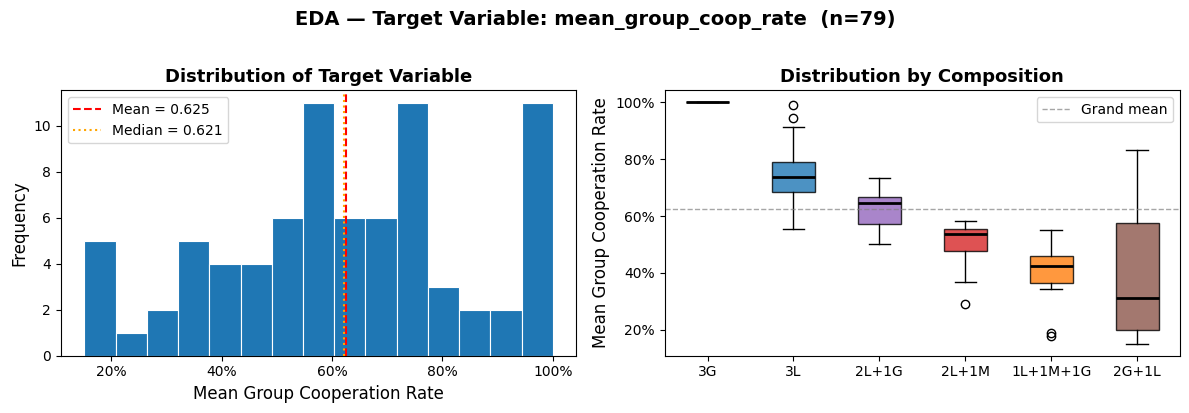

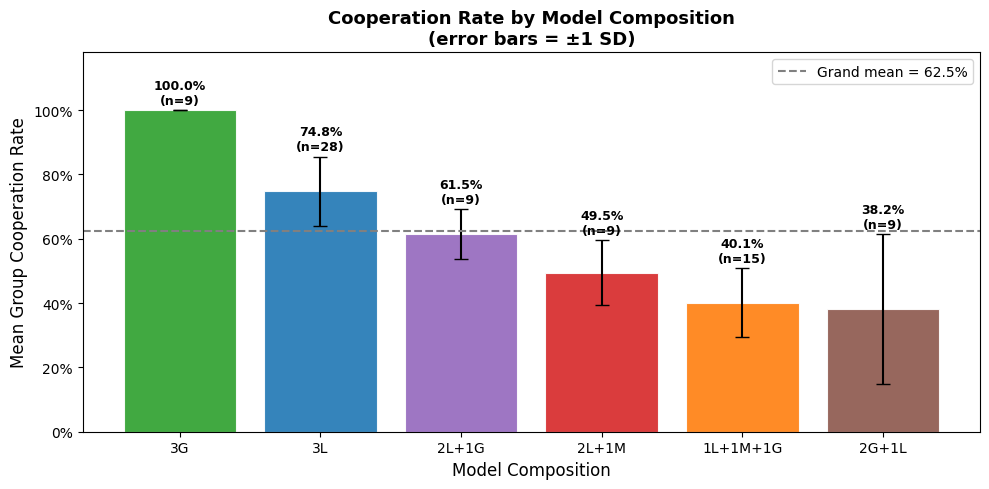

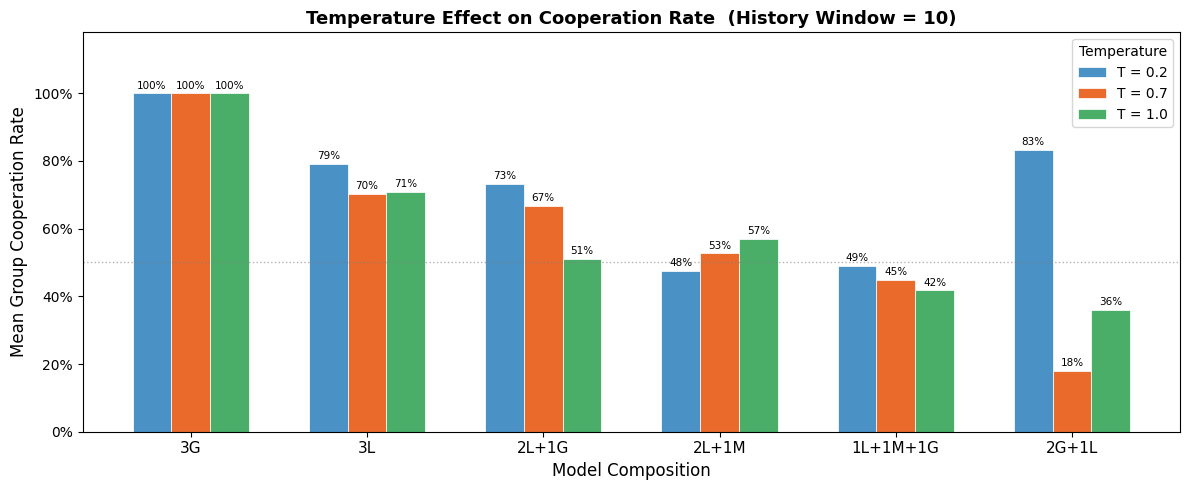

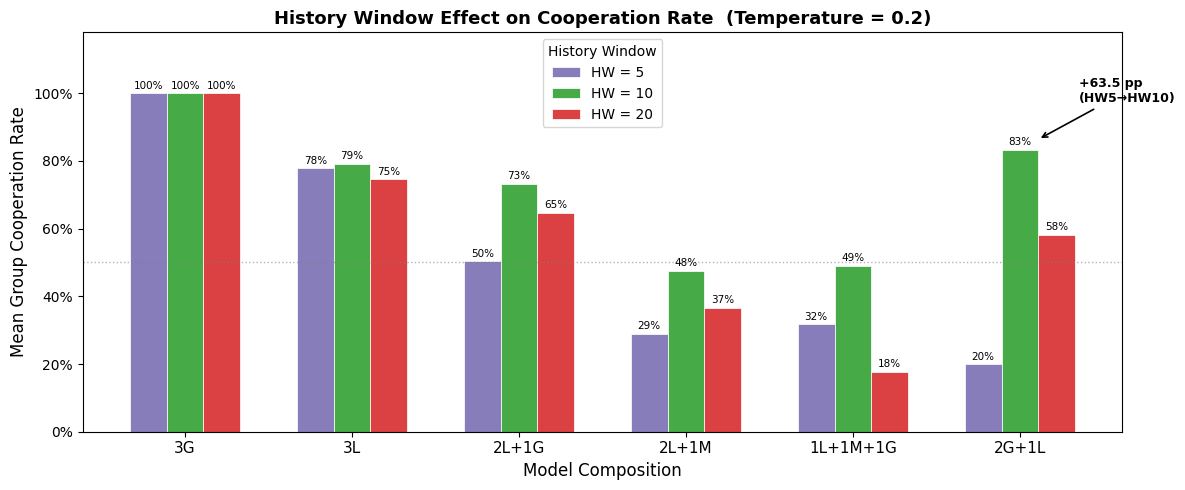

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import os # <--- ADDED THIS

# ── Load dataset ──────────────────────────────────────────────────────────────
# Ensure this path matches your environment
df = pd.read_csv("/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/csv_output/enriched_registry.csv")

# Ensure the 'figures' directory exists before trying to save into it
os.makedirs("figures", exist_ok=True) # <--- ADDED THIS

COMP_ORDER = ["3G", "3L", "2L+1G", "2L+1M", "1L+1M+1G", "2G+1L"]
COMP_COLORS = {
    "3G":       "#2ca02c",
    "3L":       "#1f77b4",
    "2L+1G":    "#9467bd",
    "2G+1L":    "#8c564b",
    "2L+1M":    "#d62728",
    "1L+1M+1G": "#ff7f0e",
}
palette = [COMP_COLORS[c] for c in COMP_ORDER]

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — Target Variable Distribution: mean_group_coop_rate
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df["mean_group_coop_rate"], bins=15,
    color="#1f77b4", edgecolor="white", linewidth=0.8
)
axes[0].axvline(df["mean_group_coop_rate"].mean(), color="red",
                linestyle="--", linewidth=1.5, label=f"Mean = {df['mean_group_coop_rate'].mean():.3f}")
axes[0].axvline(df["mean_group_coop_rate"].median(), color="orange",
                linestyle=":", linewidth=1.5, label=f"Median = {df['mean_group_coop_rate'].median():.3f}")
axes[0].set_xlabel("Mean Group Cooperation Rate", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Distribution of Target Variable", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Box plot coloured by composition
bp_data = [df[df["model_mix_label"] == c]["mean_group_coop_rate"].values for c in COMP_ORDER]
bp = axes[1].boxplot(bp_data, patch_artist=True, notch=False,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(COMP_ORDER, fontsize=10)
axes[1].set_ylabel("Mean Group Cooperation Rate", fontsize=12)
axes[1].set_title("Distribution by Composition", fontsize=13, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].axhline(df["mean_group_coop_rate"].mean(), color="gray",
                linestyle="--", linewidth=1, alpha=0.7, label="Grand mean")
axes[1].legend(fontsize=10)

fig.suptitle("EDA — Target Variable: mean_group_coop_rate  (n=79)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/EDA_01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Cooperation Rate by Model Composition (bar chart with error bars)
# ══════════════════════════════════════════════════════════════════════════════
stats = (
    df.groupby("model_mix_label")["mean_group_coop_rate"]
    .agg(["mean", "std", "count"])
    .loc[COMP_ORDER]
    .reset_index()
)
stats["se"] = stats["std"] / np.sqrt(stats["count"])   # standard error

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    stats["model_mix_label"], stats["mean"],
    yerr=stats["std"], capsize=5, error_kw=dict(linewidth=1.5),
    color=palette, edgecolor="white", linewidth=0.8, alpha=0.9
)

for bar, (_, row) in zip(bars, stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row["mean"] + row["std"] + 0.01,
        f"{row['mean']*100:.1f}%\n(n={int(row['count'])})",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax.axhline(df["mean_group_coop_rate"].mean(), color="gray",
           linestyle="--", linewidth=1.5, label=f"Grand mean = {df['mean_group_coop_rate'].mean()*100:.1f}%")
ax.set_xlabel("Model Composition", fontsize=12)
ax.set_ylabel("Mean Group Cooperation Rate", fontsize=12)
ax.set_title("Cooperation Rate by Model Composition\n(error bars = ±1 SD)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.18)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/EDA_02_coop_by_composition.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Temperature Effect (HW=10 fixed)
# ══════════════════════════════════════════════════════════════════════════════
df_hw10 = df[df["history_window"] == 10].copy()
temps = [0.2, 0.7, 1.0]

temp_means = (
    df_hw10.groupby(["model_mix_label", "temperature"])["mean_group_coop_rate"]
    .mean()
    .unstack("temperature")
    .loc[COMP_ORDER, temps]
)

x = np.arange(len(COMP_ORDER))
width = 0.22
fig, ax = plt.subplots(figsize=(12, 5))

for i, temp in enumerate(temps):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, temp_means[temp], width,
                  label=f"T = {temp}",
                  color=["#3182bd", "#e6550d", "#31a354"][i],
                  edgecolor="white", linewidth=0.6, alpha=0.88)
    for bar, val in zip(bars, temp_means[temp]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.008, f"{val*100:.0f}%",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(COMP_ORDER, fontsize=11)
ax.set_ylabel("Mean Group Cooperation Rate", fontsize=12)
ax.set_xlabel("Model Composition", fontsize=12)
ax.set_title("Temperature Effect on Cooperation Rate  (History Window = 10)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.18)
ax.legend(title="Temperature", fontsize=10, title_fontsize=10)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6)
plt.tight_layout()
plt.savefig("figures/EDA_03_temperature_effect.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot 4 — History Window Effect (T=0.2 fixed)
# ══════════════════════════════════════════════════════════════════════════════
df_t02 = df[df["temperature"] == 0.2].copy()
hws = [5, 10, 20]

hw_means = (
    df_t02.groupby(["model_mix_label", "history_window"])["mean_group_coop_rate"]
    .mean()
    .unstack("history_window")
    .loc[COMP_ORDER, hws]
)

fig, ax = plt.subplots(figsize=(12, 5))

for i, hw in enumerate(hws):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, hw_means[hw], width,
                  label=f"HW = {hw}",
                  color=["#756bb1", "#2ca02c", "#d62728"][i],
                  edgecolor="white", linewidth=0.6, alpha=0.88)
    for bar, val in zip(bars, hw_means[hw]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.008, f"{val*100:.0f}%",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(COMP_ORDER, fontsize=11)
ax.set_ylabel("Mean Group Cooperation Rate", fontsize=12)
ax.set_xlabel("Model Composition", fontsize=12)
ax.set_title("History Window Effect on Cooperation Rate  (Temperature = 0.2)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.18)
ax.legend(title="History Window", fontsize=10, title_fontsize=10)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6)

# Annotate largest gain
ax.annotate(
    "+63.5 pp\n(HW5→HW10)",
    xy=(x[COMP_ORDER.index("2G+1L")] + width * 0.5, hw_means.loc["2G+1L", 10] + 0.03),
    xytext=(x[COMP_ORDER.index("2G+1L")] + width * 1.6, hw_means.loc["2G+1L", 10] + 0.14),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    fontsize=9, color="black", fontweight="bold"
)

plt.tight_layout()
plt.savefig("figures/EDA_04_history_window_effect.png", dpi=150, bbox_inches="tight")
plt.show()

In [2]:
# ── Shared prereqs (run once before any CR1.xx cell) ─────────────────────────
import json, glob, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm

FOLDERS = {
    "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
    "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
    "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
    "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
    "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
    "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
}
COMP_COLORS = {
    "3Llama":"#1f77b4","3Gemma":"#2ca02c","2L+1G":"#9467bd",
    "2G+1L":"#8c564b","2L+1M":"#d62728","1L+1M+1G":"#ff7f0e",
}
COMPS = list(FOLDERS.keys())
TEMPS = [0.2, 0.7, 1.0]
HWS   = [5, 10, 20]

SCOT_ALL = {
    "3Llama":    {"CC":57.7,"CD":16.8,"DC":15.9,"DD": 9.6},
    "3Gemma":    {"CC":100.,"CD": 0.0,"DC": 0.0,"DD": 0.0},
    "2L+1G":     {"CC":49.1,"CD":12.6,"DC":11.8,"DD":26.5},
    "2G+1L":     {"CC":33.0,"CD": 5.3,"DC": 4.6,"DD":57.0},
    "2L+1M":     {"CC":29.3,"CD":20.6,"DC":19.2,"DD":31.0},
    "1L+1M+1G":  {"CC":30.8,"CD":11.2,"DC":10.0,"DD":48.0},
}

# ── Cooperation-rate loaders ──────────────────────────────────────────────────

def cond_coops_all():
    """
    Read T and HW from config block inside each JSON.
    Returns {comp: {(T, HW): mean_group_coop_pct}}.
    """
    out = {comp: {} for comp in FOLDERS}
    for comp, folder in FOLDERS.items():
        buckets = {}
        for fp in sorted(glob.glob(f"{folder}/*.json")):
            with open(fp) as f:
                d = json.load(f)
            T  = d["config"]["temperature"]
            HW = d["config"]["history_window_size"]
            key = (round(T, 1), HW)
            for ep in d["episodes"]:
                rates = []
                for i in range(3):
                    ag = ep.get(f"agent_{i}", {})
                    if "cooperation_rate" in ag:
                        rates.append(ag["cooperation_rate"] * 100.0)
                if rates:
                    buckets.setdefault(key, []).extend(rates)
        out[comp] = {k: float(np.mean(v)) for k, v in buckets.items()}
    return out

def episode_coops_all():
    """
    Returns {comp: np.array of per-episode mean group cooperation rate (%)}.
    One value per episode across all 9 files × 50 episodes = 450 values per comp.
    """
    out = {}
    for comp, folder in FOLDERS.items():
        coops = []
        for fp in sorted(glob.glob(f"{folder}/*.json")):
            with open(fp) as f:
                d = json.load(f)
            for ep in d["episodes"]:
                rates = []
                for i in range(3):
                    ag = ep.get(f"agent_{i}", {})
                    if "cooperation_rate" in ag:
                        rates.append(ag["cooperation_rate"] * 100.0)
                coops.append(float(np.mean(rates)) if rates else 0.0)
        out[comp] = np.array(coops)
    return out

def make_grid_coop(cond_dict):
    """Build 3×3 numpy grid (rows=temps, cols=HWs) from {(T,HW):value} dict."""
    g = np.zeros((3, 3))
    for ri, t in enumerate(TEMPS):
        for ci, hw in enumerate(HWS):
            g[ri, ci] = cond_dict.get((round(t,1), hw), np.nan)
    return g

# Load once — reused by all CR1.xx cells
print("Loading cooperation rates from JSONs (this may take ~30s)...")
ALL_COOP_COND = cond_coops_all()   # {comp: {(T,HW): mean coop %}}
ALL_COOP_EP   = episode_coops_all()  # {comp: np.array of 450 values}
print("Done. Condition means:")
for comp in COMPS:
    vals = list(ALL_COOP_COND[comp].values())
    print(f"  {comp:<12}: mean={np.mean(vals):.1f}%  min={np.min(vals):.1f}%  max={np.max(vals):.1f}%")

Loading cooperation rates from JSONs (this may take ~30s)...
Done. Condition means:
  3Llama      : mean=74.3%  min=61.5%  max=94.4%
  3Gemma      : mean=100.0%  min=100.0%  max=100.0%
  2L+1G       : mean=61.5%  min=50.3%  max=73.3%
  2G+1L       : mean=38.2%  min=15.1%  max=83.4%
  2L+1M       : mean=49.5%  min=28.9%  max=58.3%
  1L+1M+1G    : mean=41.6%  min=17.7%  max=52.5%


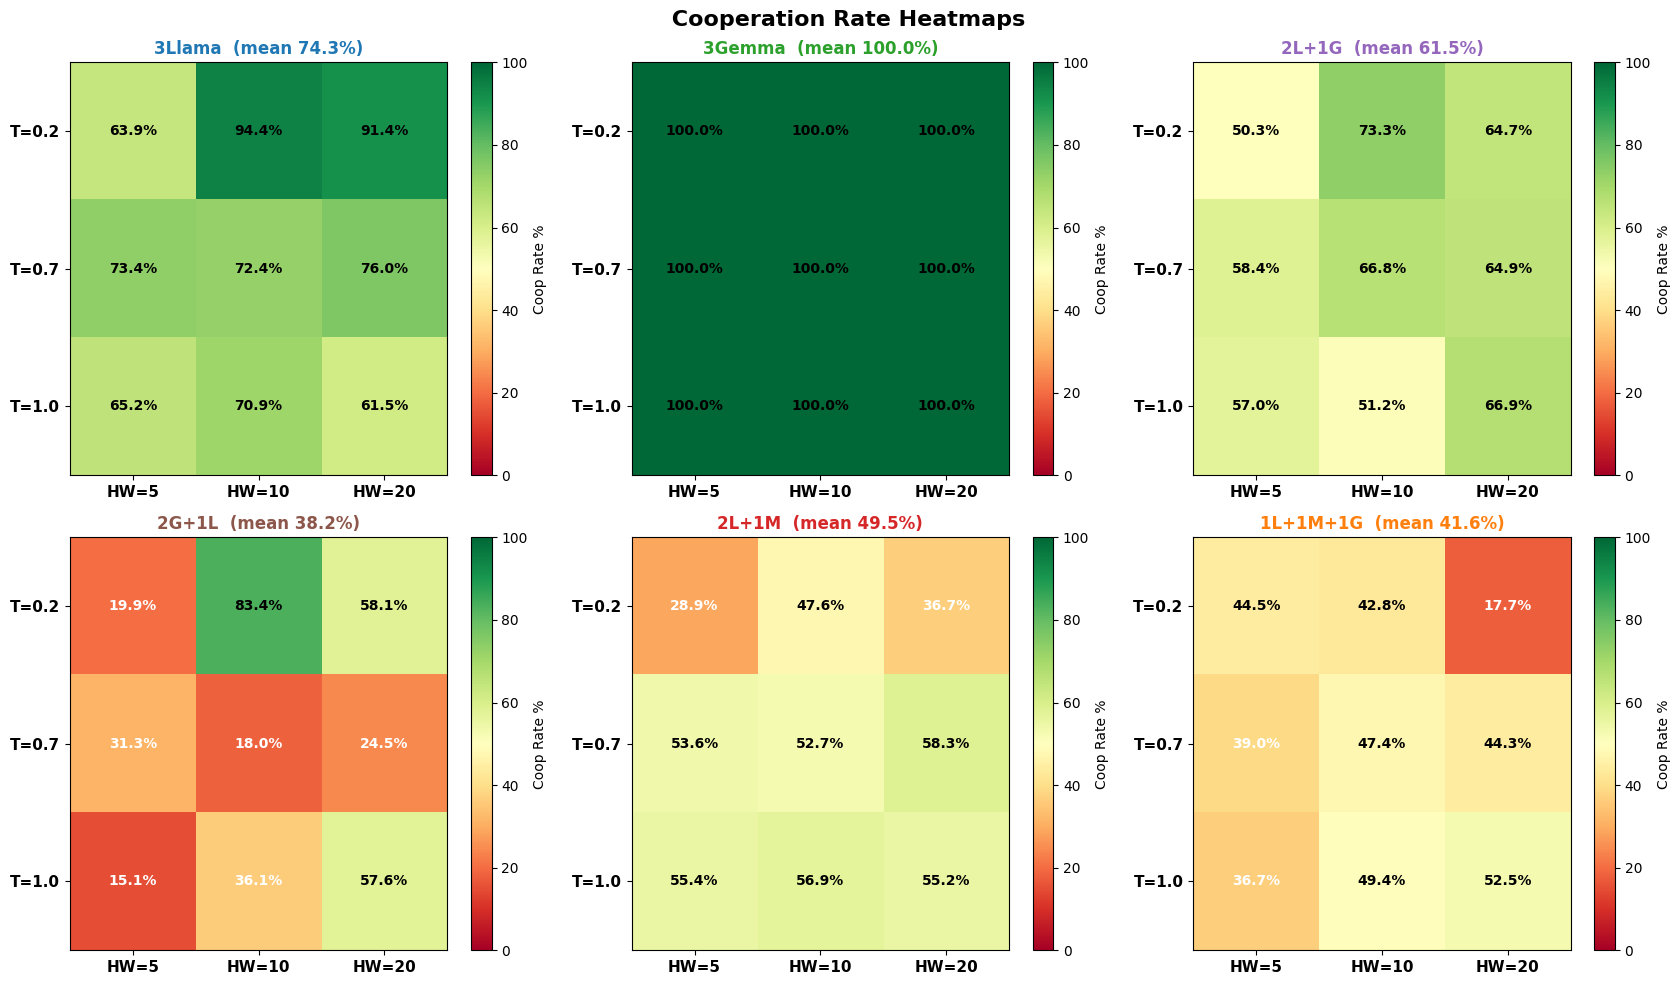

Saved: CR1_01_coop_heatmaps_11.svg


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# ... [Assume COMPS, ALL_COOP_COND, make_grid_coop, COMP_COLORS are defined] ...

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(" Cooperation Rate Heatmaps", fontsize=16, fontweight="bold")
norm = Normalize(vmin=0, vmax=100)

for idx, comp in enumerate(COMPS):
    ax = axes[idx // 3, idx % 3]
    grid = make_grid_coop(ALL_COOP_COND[comp])
    im = ax.imshow(grid, norm=norm, cmap="RdYlGn", aspect="auto")

    for ri in range(3):
        for ci in range(3):
            v = grid[ri, ci]
            color = "white" if v < 40 else "black"
            ax.text(ci, ri, f"{v:.1f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=color)

    # UPDATED: Added fontweight="bold" and increased fontsize slightly
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["HW=5", "HW=10", "HW=20"], fontsize=11, fontweight="bold")
    
    # UPDATED: Added fontweight="bold" and increased fontsize slightly
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["T=0.2", "T=0.7", "T=1.0"], fontsize=11, fontweight="bold")
    
    mean_v = np.nanmean(grid)
    ax.set_title(f"{comp}  (mean {mean_v:.1f}%)", fontsize=12,
                 fontweight="bold", color=COMP_COLORS[comp])
    plt.colorbar(im, ax=ax, label="Coop Rate %")

plt.tight_layout()

# UPDATED: Saved as an SVG instead of PNG. This is the silver bullet for PowerPoint.
plt.savefig("CR1_01_coop_heatmaps_12.svg", format="svg", bbox_inches="tight")
plt.show()
print("Saved: CR1_01_coop_heatmaps_11.svg")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: VADER Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure VADER is available ────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    vader_ok = True
except ImportError:
    print("Error: vaderSentiment not installed. Please run: pip install vaderSentiment")
    vader_ok = False

if vader_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        scores.append(sia.polarity_scores(refl)["compound"])
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    # Sort models by cooperation rate (high at top) for visual alignment
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    # Panel 1 is wider for the line chart, Panel 2 is for horizontal bars
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean VADER Compound Sentiment", fontsize=11, fontweight="bold")
    
    # Updated Y-axis limits
    ax_traj.set_ylim(-1.0, 1.0)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    # Re-enabled Y-labels so you can see model names
    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    plt.savefig("B2_Combined_Sentiment_Trajectory_Coop_21.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nSaved: B2_Combined_Sentiment_Trajectory_Coop_11.png")

Extracting Sentiment and Cooperation Rates... (This may take a moment)


/tmp/ipykernel_4149176/704753472.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


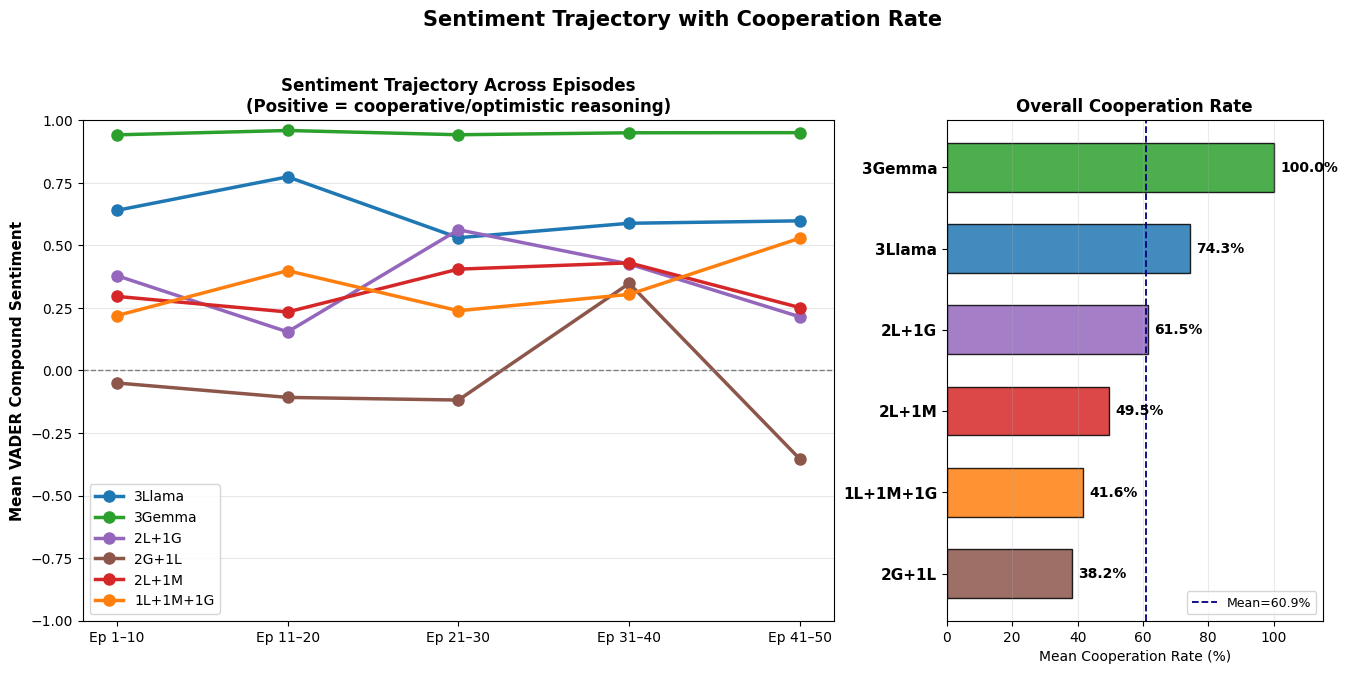


Saved: B2_Combined_Sentiment_Trajectory_Coop_20.svg


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: VADER Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure VADER is available ────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    vader_ok = True
except ImportError:
    print("Error: vaderSentiment not installed. Please run: pip install vaderSentiment")
    vader_ok = False

if vader_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        scores.append(sia.polarity_scores(refl)["compound"])
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    # Sort models by cooperation rate (high at top) for visual alignment
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    # Panel 1 is wider for the line chart, Panel 2 is for horizontal bars
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean VADER Compound Sentiment", fontsize=11, fontweight="bold")
    
    # Updated Y-axis limits
    ax_traj.set_ylim(-1.0, 1.0)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    # Re-enabled Y-labels so you can see model names
    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── UPDATED EXPORT SECTION ───────────────────────────────────────────────
    # Saving as a vector graphic (.svg) to ensure perfect clarity in PowerPoint
    plt.savefig("B2_Combined_Sentiment_Trajectory_Coop_20.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("\nSaved: B2_Combined_Sentiment_Trajectory_Coop_20.svg")

Extracting Sentiment and Cooperation Rates... (This may take a moment)


/tmp/ipykernel_4149176/2803123572.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


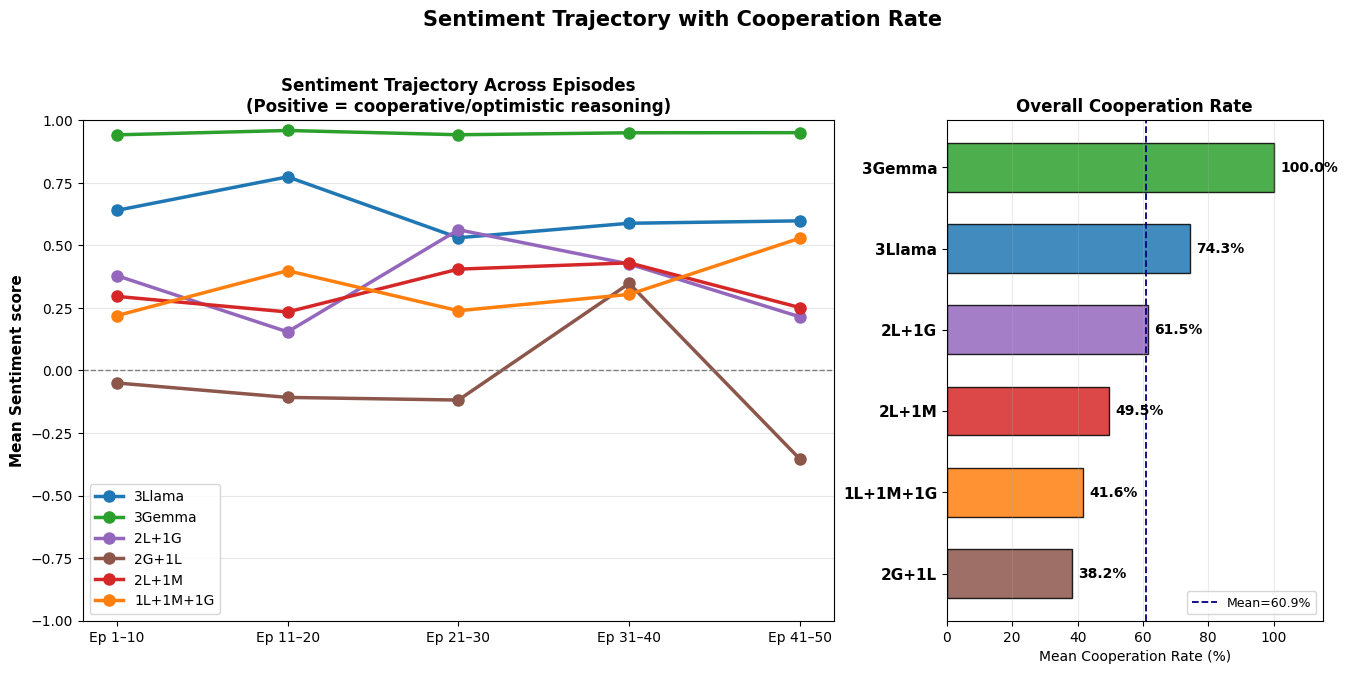


Saved: B2_Combined_Sentiment_Trajectory_Coop_20.svg


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: VADER Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure VADER is available ────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    vader_ok = True
except ImportError:
    print("Error: vaderSentiment not installed. Please run: pip install vaderSentiment")
    vader_ok = False

if vader_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        scores.append(sia.polarity_scores(refl)["compound"])
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    # Sort models by cooperation rate (high at top) for visual alignment
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    # Panel 1 is wider for the line chart, Panel 2 is for horizontal bars
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean Sentiment score", fontsize=11, fontweight="bold")
    
    # Updated Y-axis limits
    ax_traj.set_ylim(-1.0, 1.0)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    # Re-enabled Y-labels so you can see model names
    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── UPDATED EXPORT SECTION ───────────────────────────────────────────────
    # Saving as a vector graphic (.svg) to ensure perfect clarity in PowerPoint
    plt.savefig("B2_Combined_Sentiment_Trajectory_Coop_24.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("\nSaved: B2_Combined_Sentiment_Trajectory_Coop_20.svg")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/home/rayudu/My_work1/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)


/tmp/ipykernel_4149176/469304374.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


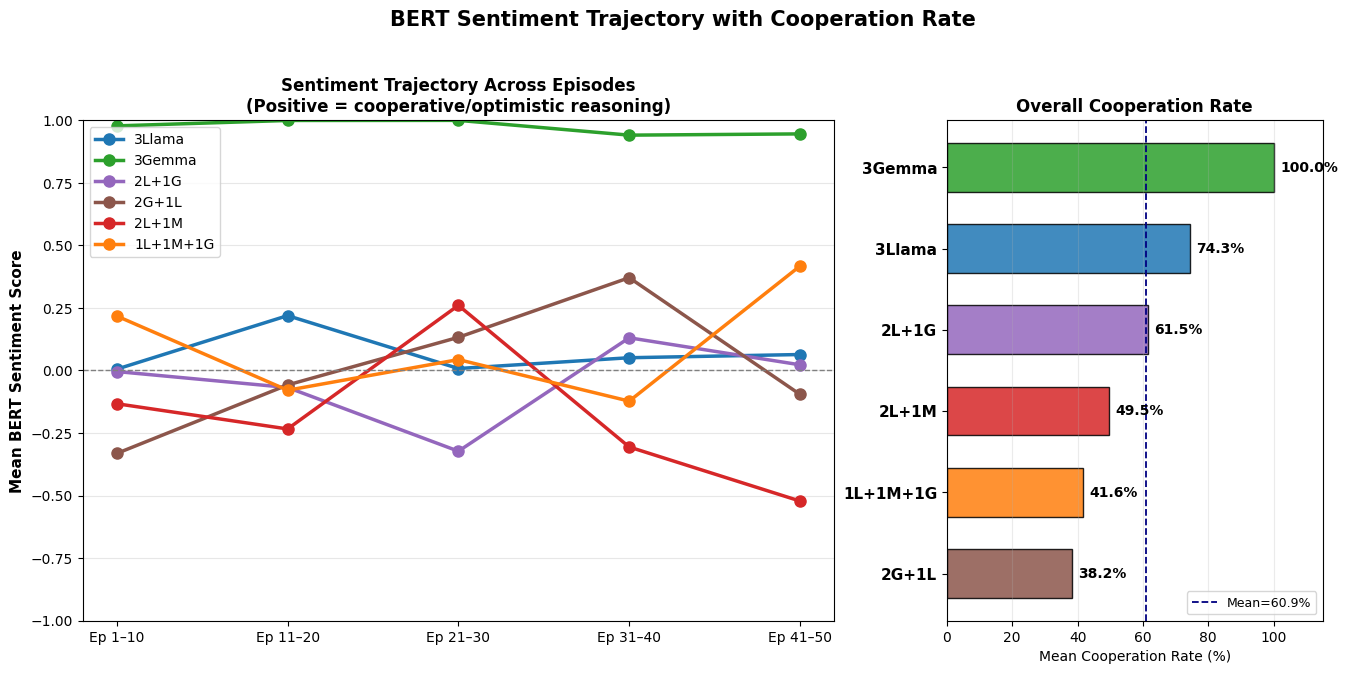


Saved: B2_Combined_BERT_Trajectory_Coop_20.svg


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: BERT Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure Hugging Face Transformers is available ────────────────────────────
try:
    from transformers import pipeline
    # Initialize the default sentiment pipeline (DistilBERT SST-2)
    # truncation=True ensures it doesn't crash on reflections longer than 512 tokens
    sentiment_pipeline = pipeline("sentiment-analysis", truncation=True, max_length=512)
    bert_ok = True
except ImportError:
    print("Error: transformers not installed. Please run: pip install transformers torch")
    bert_ok = False

if bert_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory using BERT
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        # Run BERT inference
                        result = sentiment_pipeline(refl)[0]
                        
                        # Map BERT output to VADER's -1.0 to 1.0 scale
                        # BERT returns a dict like {'label': 'POSITIVE', 'score': 0.99}
                        score_val = result['score']
                        compound = score_val if result['label'] == 'POSITIVE' else -score_val
                        scores.append(compound)
                        
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean BERT Sentiment Score", fontsize=11, fontweight="bold")
    
    ax_traj.set_ylim(-1.0, 1.0)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "BERT Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── EXPORT SECTION ───────────────────────────────────────────────────────
    plt.savefig("B2_Combined_BERT_Trajectory_Coop_20.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("\nSaved: B2_Combined_BERT_Trajectory_Coop_20.svg")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)

DATA SUMMARY: BERT SENTIMENT & COOPERATION RATES

► Model Composition: 3Llama
  Overall Cooperation Rate: 74.3%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.0053
    Block 2 (Ep 11-20): +0.2192
    Block 3 (Ep 21-30): +0.0078
    Block 4 (Ep 31-40): +0.0509
    Block 5 (Ep 41-50): +0.0637

► Model Composition: 3Gemma
  Overall Cooperation Rate: 100.0%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.9774
    Block 2 (Ep 11-20): +0.9990
    Block 3 (Ep 21-30): +0.9994
    Block 4 (Ep 31-40): +0.9404
    Block 5 (Ep 41-50): +0.9453

► Model Composition: 2L+1G
  Overall Cooperation Rate: 61.5%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): -0.0043
    Block 2 (Ep 11-20): -0.0680
    Block 3 (Ep 21-30): -0.3226
    Block 4 (Ep 31-40): +0.1306
    Block 5 (Ep 41-50): +0.0226

► Model Composition: 2G+1L
  Overall Cooperation Rate: 38.2%
  

/tmp/ipykernel_4149176/3075756636.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


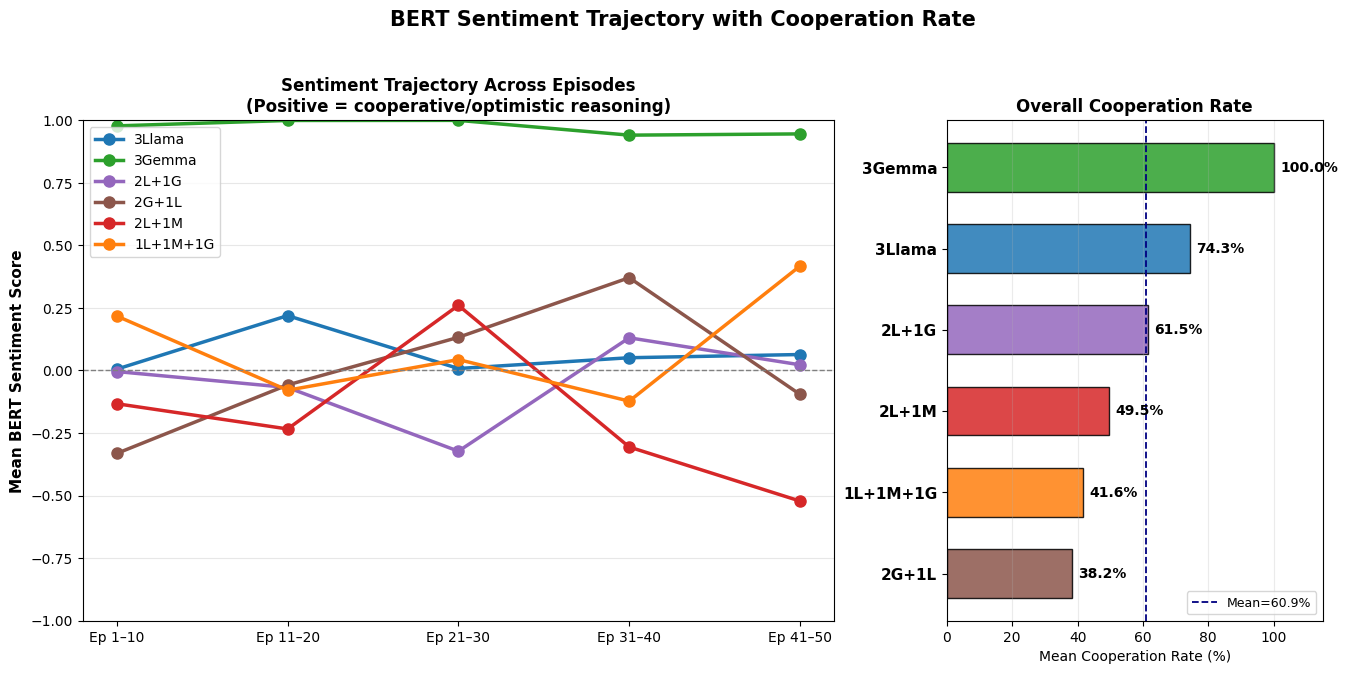

Saved: B2_Combined_BERT_Trajectory_Coop_20.svg


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: BERT Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure Hugging Face Transformers is available ────────────────────────────
try:
    from transformers import pipeline
    # Initialize the default sentiment pipeline (DistilBERT SST-2)
    # truncation=True ensures it doesn't crash on reflections longer than 512 tokens
    sentiment_pipeline = pipeline("sentiment-analysis", truncation=True, max_length=512)
    bert_ok = True
except ImportError:
    print("Error: transformers not installed. Please run: pip install transformers torch")
    bert_ok = False

if bert_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory using BERT
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        # Run BERT inference
                        result = sentiment_pipeline(refl)[0]
                        
                        # Map BERT output to VADER's -1.0 to 1.0 scale
                        score_val = result['score']
                        compound = score_val if result['label'] == 'POSITIVE' else -score_val
                        scores.append(compound)
                        
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── NEW: PRINT CONSOLE SUMMARY ───────────────────────────────────────────
    print("\n" + "="*60)
    print("DATA SUMMARY: BERT SENTIMENT & COOPERATION RATES")
    print("="*60)
    for comp in COMPS:
        print(f"\n► Model Composition: {comp}")
        print(f"  Overall Cooperation Rate: {comp_overall_coop[comp]:.1f}%")
        print("  Sentiment Trajectory (by 10-episode blocks):")
        for i, val in enumerate(comp_sentiment_trajectory[comp]):
            print(f"    Block {i+1} (Ep {i*10+1:02d}-{i*10+10}): {val:+.4f}")
    print("\n" + "="*60 + "\n")

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean BERT Sentiment Score", fontsize=11, fontweight="bold")
    
    ax_traj.set_ylim(-1.0, 1.0)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "BERT Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── EXPORT SECTION ───────────────────────────────────────────────────────
    plt.savefig("B2_Combined_BERT_Trajectory_Coop_20.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Saved: B2_Combined_BERT_Trajectory_Coop_20.svg")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting RoBERTa Sentiment and Cooperation Rates... (This will take longer than DistilBERT)

DATA SUMMARY: RoBERTa SENTIMENT & COOPERATION RATES

► Model Composition: 3Llama
  Overall Cooperation Rate: 74.3%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.5787
    Block 2 (Ep 11-20): +0.6293
    Block 3 (Ep 21-30): +0.5564
    Block 4 (Ep 31-40): +0.5355
    Block 5 (Ep 41-50): +0.4666

► Model Composition: 3Gemma
  Overall Cooperation Rate: 100.0%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.9751
    Block 2 (Ep 11-20): +0.9705
    Block 3 (Ep 21-30): +0.9724
    Block 4 (Ep 31-40): +0.9742
    Block 5 (Ep 41-50): +0.9706

► Model Composition: 2L+1G
  Overall Cooperation Rate: 61.5%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.2740
    Block 2 (Ep 11-20): +0.3541
    Block 3 (Ep 21-30): +0.2475
    Block 4 (Ep 31-40): +0.4305
    Block 5 (Ep 41-50): +0.2947

► Model Composition: 2G+1L
  Overall Coope

/tmp/ipykernel_4149176/2957029201.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


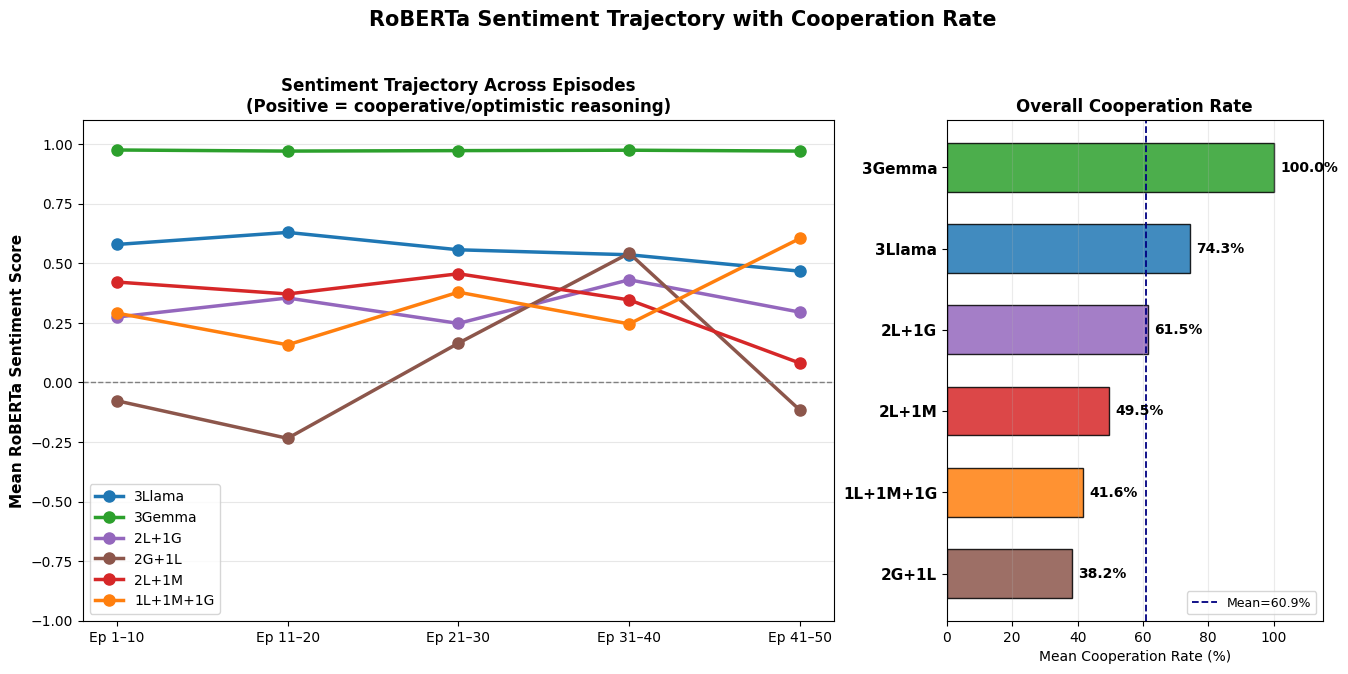

Saved: B2_Combined_RoBERTa_Trajectory_Coop.svg


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: RoBERTa Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure Hugging Face Transformers is available ────────────────────────────
try:
    from transformers import pipeline
    # Initialize the Twitter RoBERTa model (3-class: Positive, Neutral, Negative)
    # top_k=None ensures it returns the probability for ALL 3 classes
    sentiment_pipeline = pipeline(
        "sentiment-analysis", 
        model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
        truncation=True, 
        max_length=512
    )
    bert_ok = True
except ImportError:
    print("Error: transformers not installed. Please run: pip install transformers torch")
    bert_ok = False

if bert_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting RoBERTa Sentiment and Cooperation Rates... (This will take longer than DistilBERT)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory using RoBERTa
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        # Run RoBERTa inference
                        raw_results = sentiment_pipeline(refl, top_k=None)
                        
                        # Handle HF version differences (list of lists vs flat list)
                        if isinstance(raw_results[0], list):
                            results = raw_results[0]
                        else:
                            results = raw_results
                        
                        # Extract specific probabilities by label safely with fallbacks
                        p_pos = next((item['score'] for item in results if item['label'].lower() == 'positive'), 0.0)
                        p_neg = next((item['score'] for item in results if item['label'].lower() == 'negative'), 0.0)
                        
                        # Calculate Expected Value on [-1, 1] scale
                        # Formula: P(positive) - P(negative). Neutral probability naturally pulls it to 0.
                        compound = p_pos - p_neg
                        scores.append(compound)
                        
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── PRINT CONSOLE SUMMARY ────────────────────────────────────────────────
    print("\n" + "="*60)
    print("DATA SUMMARY: RoBERTa SENTIMENT & COOPERATION RATES")
    print("="*60)
    for comp in COMPS:
        print(f"\n► Model Composition: {comp}")
        print(f"  Overall Cooperation Rate: {comp_overall_coop[comp]:.1f}%")
        print("  Sentiment Trajectory (by 10-episode blocks):")
        for i, val in enumerate(comp_sentiment_trajectory[comp]):
            print(f"    Block {i+1} (Ep {i*10+1:02d}-{i*10+10}): {val:+.4f}")
    print("\n" + "="*60 + "\n")

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean RoBERTa Sentiment Score", fontsize=11, fontweight="bold")
    
    ax_traj.set_ylim(-1.0, 1.1)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "RoBERTa Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── EXPORT SECTION ───────────────────────────────────────────────────────
    plt.savefig("B2_Combined_RoBERTa_Trajectory_Coop.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Saved: B2_Combined_RoBERTa_Trajectory_Coop.svg")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)

DATA SUMMARY: BERT SENTIMENT & COOPERATION RATES

► Model Composition: 3Llama
  Overall Cooperation Rate: 74.3%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.0053
    Block 2 (Ep 11-20): +0.2192
    Block 3 (Ep 21-30): +0.0078
    Block 4 (Ep 31-40): +0.0509
    Block 5 (Ep 41-50): +0.0637

► Model Composition: 3Gemma
  Overall Cooperation Rate: 100.0%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.9774
    Block 2 (Ep 11-20): +0.9990
    Block 3 (Ep 21-30): +0.9994
    Block 4 (Ep 31-40): +0.9404
    Block 5 (Ep 41-50): +0.9453

► Model Composition: 2L+1G
  Overall Cooperation Rate: 61.5%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): -0.0043
    Block 2 (Ep 11-20): -0.0680
    Block 3 (Ep 21-30): -0.3226
    Block 4 (Ep 31-40): +0.1306
    Block 5 (Ep 41-50): +0.0226

► Model Composition: 2G+1L
  Overall Cooperation Rate: 38.2%
  

/tmp/ipykernel_4149176/1302666462.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


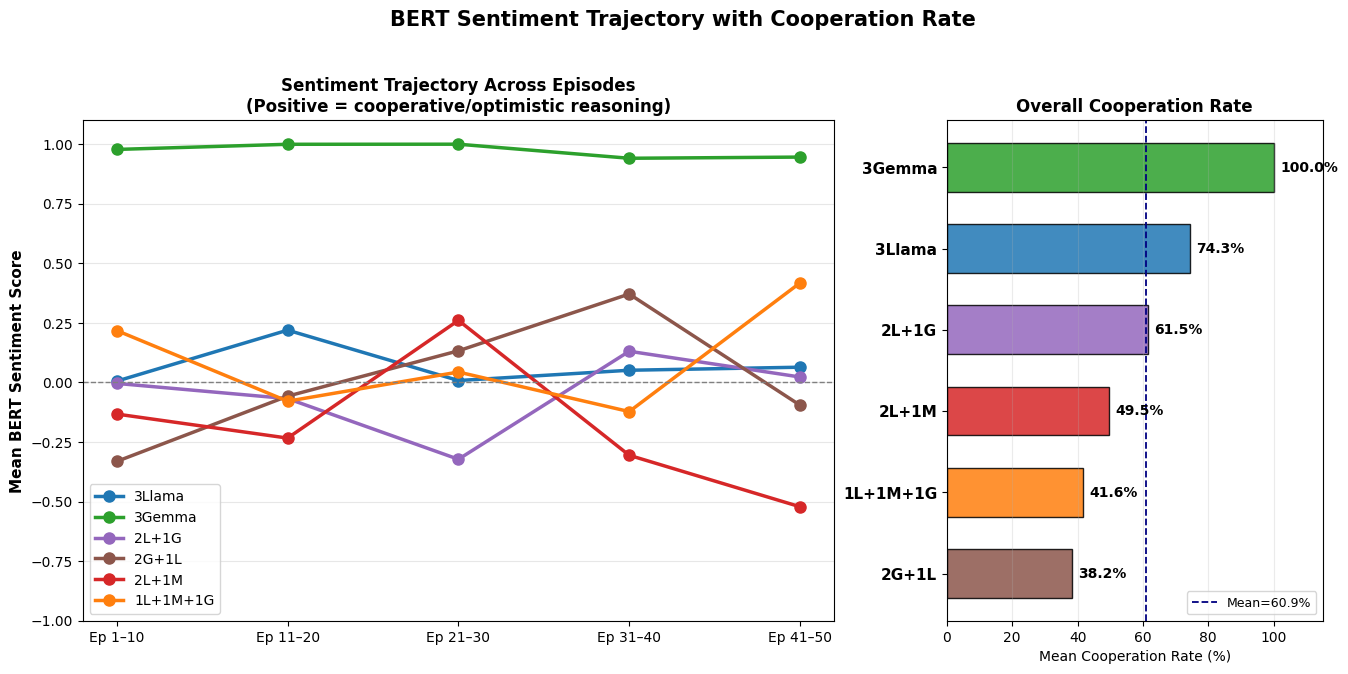

Saved: B2_Combined_BERT_Trajectory_Coop_20.svg


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: BERT Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure Hugging Face Transformers is available ────────────────────────────
try:
    from transformers import pipeline
    # Initialize the default sentiment pipeline (DistilBERT SST-2)
    # truncation=True ensures it doesn't crash on reflections longer than 512 tokens
    sentiment_pipeline = pipeline("sentiment-analysis", truncation=True, max_length=512)
    bert_ok = True
except ImportError:
    print("Error: transformers not installed. Please run: pip install transformers torch")
    bert_ok = False

if bert_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting BERT Sentiment and Cooperation Rates... (This may take a moment)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory using BERT
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        # Run BERT inference
                        result = sentiment_pipeline(refl)[0]
                        
                        # Map BERT output to VADER's -1.0 to 1.0 scale
                        score_val = result['score']
                        compound = score_val if result['label'] == 'POSITIVE' else -score_val
                        scores.append(compound)
                        
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── NEW: PRINT CONSOLE SUMMARY ───────────────────────────────────────────
    print("\n" + "="*60)
    print("DATA SUMMARY: BERT SENTIMENT & COOPERATION RATES")
    print("="*60)
    for comp in COMPS:
        print(f"\n► Model Composition: {comp}")
        print(f"  Overall Cooperation Rate: {comp_overall_coop[comp]:.1f}%")
        print("  Sentiment Trajectory (by 10-episode blocks):")
        for i, val in enumerate(comp_sentiment_trajectory[comp]):
            print(f"    Block {i+1} (Ep {i*10+1:02d}-{i*10+10}): {val:+.4f}")
    print("\n" + "="*60 + "\n")

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean BERT Sentiment Score", fontsize=11, fontweight="bold")
    
    ax_traj.set_ylim(-1.0, 1.1)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "BERT Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── EXPORT SECTION ───────────────────────────────────────────────────────
    plt.savefig("B2_Combined_BERT_Trajectory_Coop_24.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Saved: B2_Combined_BERT_Trajectory_Coop_20.svg")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting RoBERTa Sentiment and Cooperation Rates... (This will take longer than DistilBERT)

DATA SUMMARY: RoBERTa SENTIMENT & COOPERATION RATES

► Model Composition: 3Llama
  Overall Cooperation Rate: 74.3%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.5787
    Block 2 (Ep 11-20): +0.6293
    Block 3 (Ep 21-30): +0.5564
    Block 4 (Ep 31-40): +0.5355
    Block 5 (Ep 41-50): +0.4666

► Model Composition: 3Gemma
  Overall Cooperation Rate: 100.0%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.9751
    Block 2 (Ep 11-20): +0.9705
    Block 3 (Ep 21-30): +0.9724
    Block 4 (Ep 31-40): +0.9742
    Block 5 (Ep 41-50): +0.9706

► Model Composition: 2L+1G
  Overall Cooperation Rate: 61.5%
  Sentiment Trajectory (by 10-episode blocks):
    Block 1 (Ep 01-10): +0.2740
    Block 2 (Ep 11-20): +0.3541
    Block 3 (Ep 21-30): +0.2475
    Block 4 (Ep 31-40): +0.4305
    Block 5 (Ep 41-50): +0.2947

► Model Composition: 2G+1L
  Overall Coope

/tmp/ipykernel_4149176/870170912.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


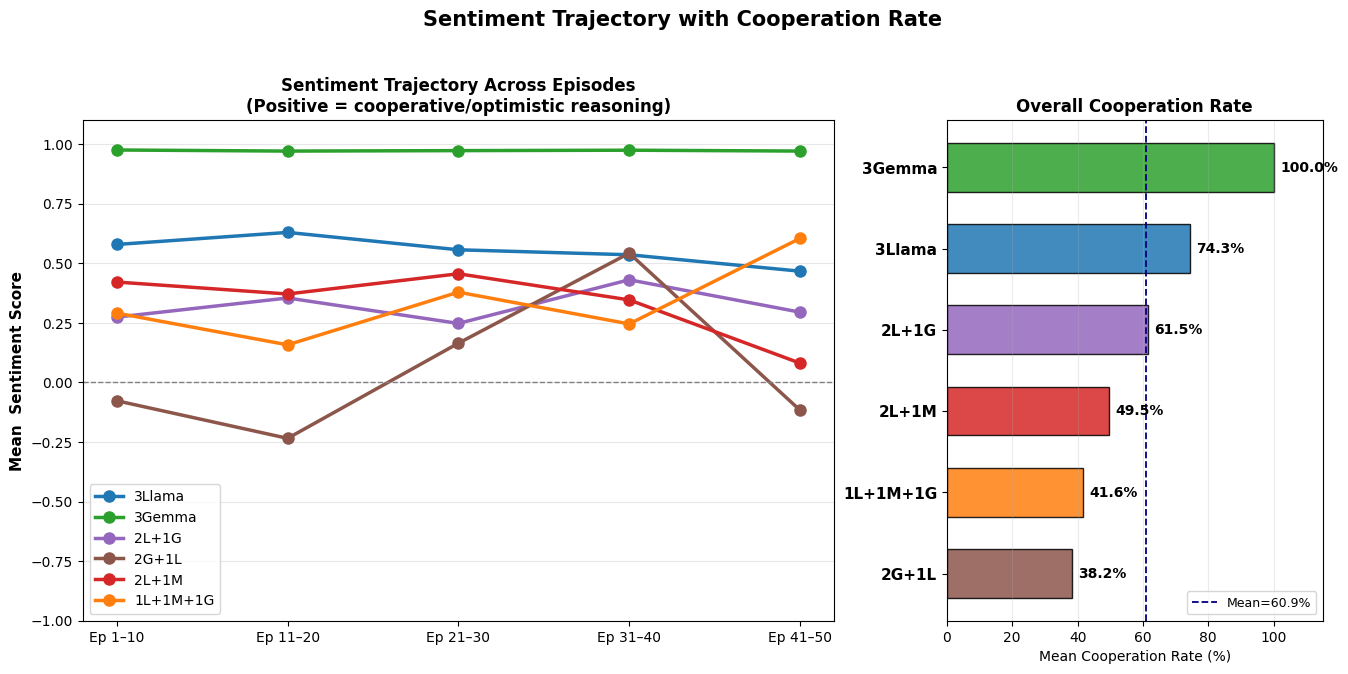

Saved: B2_Combined_RoBERTa_Trajectory_Coop.svg


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# B2.03 + B2.04 COMBINED ──────────────────────────────────────────────────────
# Sentiment Trajectory & Cooperation Rate Comparison
# Panel 1: RoBERTa Sentiment Trajectory (Line plot over episode blocks, y: -1 to 1)
# Panel 2: Overall Mean Cooperation Rate (Horizontal Bars)
# ─────────────────────────────────────────────────────────────────────────────

import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Ensure Hugging Face Transformers is available ────────────────────────────
try:
    from transformers import pipeline
    # Initialize the Twitter RoBERTa model (3-class: Positive, Neutral, Negative)
    # top_k=None ensures it returns the probability for ALL 3 classes
    sentiment_pipeline = pipeline(
        "sentiment-analysis", 
        model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
        truncation=True, 
        max_length=512
    )
    bert_ok = True
except ImportError:
    print("Error: transformers not installed. Please run: pip install transformers torch")
    bert_ok = False

if bert_ok:
    # ── Configuration ────────────────────────────────────────────────────────
    FOLDERS = {
        "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
        "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
        "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
        "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
        "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
        "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
    }
    COMP_COLORS = {
        "3Llama":"#1f77b4", "3Gemma":"#2ca02c", "2L+1G":"#9467bd",
        "2G+1L":"#8c564b",  "2L+1M":"#d62728",  "1L+1M+1G":"#ff7f0e",
    }
    COMPS = list(FOLDERS.keys())
    
    BLOCK_SIZE = 10
    N_BLOCKS = 5

    print("Extracting RoBERTa Sentiment and Cooperation Rates... (This will take longer than DistilBERT)")

    # ── Step 1: Data Extraction ──────────────────────────────────────────────
    comp_sentiment_trajectory = {}
    comp_overall_coop = {}

    for comp, folder in FOLDERS.items():
        files = sorted(glob.glob(f"{folder}/*.json"))
        
        all_reflections = []  # list of (ep_num, sentiment_score)
        rates = []
        ep_counter = 0
        
        for fp in files:
            with open(fp) as f:
                d = json.load(f)
                
            # A. Extract Overall Cooperation
            for i in range(3):
                r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
                if r is not None:
                    rates.append(r * 100.0)
                    
            # B. Extract Sentiment from Episodes for Trajectory using RoBERTa
            for ep in d.get("episodes", []):
                scores = []
                for ag_i in range(3):
                    refl = ep.get(f"agent_{ag_i}", {}).get("reflection", "")
                    if len(refl) > 15:
                        # Run RoBERTa inference
                        raw_results = sentiment_pipeline(refl, top_k=None)
                        
                        # Handle HF version differences (list of lists vs flat list)
                        if isinstance(raw_results[0], list):
                            results = raw_results[0]
                        else:
                            results = raw_results
                        
                        # Extract specific probabilities by label safely with fallbacks
                        p_pos = next((item['score'] for item in results if item['label'].lower() == 'positive'), 0.0)
                        p_neg = next((item['score'] for item in results if item['label'].lower() == 'negative'), 0.0)
                        
                        # Calculate Expected Value on [-1, 1] scale
                        # Formula: P(positive) - P(negative). Neutral probability naturally pulls it to 0.
                        compound = p_pos - p_neg
                        scores.append(compound)
                        
                if scores:
                    all_reflections.append((ep_counter, np.mean(scores)))
                ep_counter += 1
        
        # Calculate Block Averages for Trajectory
        block_avgs = []
        for blk in range(N_BLOCKS):
            lo, hi = blk * BLOCK_SIZE, (blk + 1) * BLOCK_SIZE
            vals = [s for ep_idx, s in all_reflections if lo <= ep_idx < hi]
            block_avgs.append(np.mean(vals) if vals else 0)
            
        comp_sentiment_trajectory[comp] = block_avgs
        
        # Aggregate Overall Means
        comp_overall_coop[comp] = float(np.mean(rates)) if rates else 0.0

    # Convert to arrays for easy sorting
    coop_vals = np.array([comp_overall_coop[c] for c in COMPS])

    # ── PRINT CONSOLE SUMMARY ────────────────────────────────────────────────
    print("\n" + "="*60)
    print("DATA SUMMARY: RoBERTa SENTIMENT & COOPERATION RATES")
    print("="*60)
    for comp in COMPS:
        print(f"\n► Model Composition: {comp}")
        print(f"  Overall Cooperation Rate: {comp_overall_coop[comp]:.1f}%")
        print("  Sentiment Trajectory (by 10-episode blocks):")
        for i, val in enumerate(comp_sentiment_trajectory[comp]):
            print(f"    Block {i+1} (Ep {i*10+1:02d}-{i*10+10}): {val:+.4f}")
    print("\n" + "="*60 + "\n")

    # ── Step 2: Sorting (for the Bar Chart) ──────────────────────────────────
    order_idx    = np.argsort(coop_vals)[::-1]
    ordered_comp = [COMPS[i] for i in order_idx]
    ordered_coop = coop_vals[order_idx]
    ordered_cols = [COMP_COLORS[c] for c in ordered_comp]

    # ── Step 3: Figure Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)

    # ── PANEL 1: Sentiment Trajectory (Line Chart) ───────────────────────────
    ax_traj = fig.add_subplot(gs[0])
    x_blocks = [f"Ep {i*10+1}–{(i+1)*10}" for i in range(N_BLOCKS)]
    
    for comp in COMPS:
        ax_traj.plot(range(N_BLOCKS), comp_sentiment_trajectory[comp], "o-", 
                     color=COMP_COLORS[comp], linewidth=2.5, markersize=8, label=comp)
        
    ax_traj.set_xticks(range(N_BLOCKS))
    ax_traj.set_xticklabels(x_blocks, fontsize=10)
    ax_traj.set_ylabel("Mean  Sentiment Score", fontsize=11, fontweight="bold")
    
    ax_traj.set_ylim(-1.0, 1.1)
    ax_traj.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_traj.legend(fontsize=10, loc="best")
    ax_traj.set_title("Sentiment Trajectory Across Episodes\n(Positive = cooperative/optimistic reasoning)", fontsize=12, fontweight="bold")
    ax_traj.grid(axis="y", alpha=0.3)


    # ── PANEL 2: Overall Cooperation Rate Bars ───────────────────────────────
    y_pos = np.arange(len(COMPS))
    ax_coop = fig.add_subplot(gs[1])
    
    bars_coop = ax_coop.barh(
        y_pos, ordered_coop,
        color=ordered_cols, edgecolor="black", height=0.6, alpha=0.85
    )

    for bar, val in zip(bars_coop, ordered_coop):
        ax_coop.text(val + 2.0, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax_coop.set_yticks(y_pos)
    ax_coop.set_yticklabels(ordered_comp, fontsize=11, fontweight="bold")
    ax_coop.set_xlim(0, 115)
    ax_coop.set_xlabel("Mean Cooperation Rate (%)", fontsize=10)
    
    mean_coop = coop_vals.mean()
    ax_coop.axvline(mean_coop, color="navy", linestyle="--", linewidth=1.3, label=f"Mean={mean_coop:.1f}%")
    ax_coop.legend(fontsize=9, loc="lower right")
    ax_coop.set_title("Overall Cooperation Rate", fontsize=12, fontweight="bold")
    ax_coop.grid(axis="x", alpha=0.25)
    ax_coop.invert_yaxis()

    # ── Final Figure Touches ─────────────────────────────────────────────────
    fig.suptitle(
        "Sentiment Trajectory with Cooperation Rate",
        fontsize=15, fontweight="bold", y=1.05
    )

    plt.tight_layout()
    
    # ── EXPORT SECTION ───────────────────────────────────────────────────────
    plt.savefig("B2_Combined_RoBERTa_Trajectory_Coop_2.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Saved: B2_Combined_RoBERTa_Trajectory_Coop.svg")

In [13]:
# ── MFT01 ─────────────────────────────────────────────────────────────────────
# Moral Foundations Theory analysis of agent reasoning text
# Computes word frequency per foundation per model mix
# ─────────────────────────────────────────────────────────────────────────────
import json, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

FOLDERS = {
    "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
    "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
    "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
    "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
    "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
    "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
}
COMP_COLORS = {
    "3Llama":"#1f77b4","3Gemma":"#2ca02c","2L+1G":"#9467bd",
    "2G+1L":"#8c564b","2L+1M":"#d62728","1L+1M+1G":"#ff7f0e",
}
COMPS = list(FOLDERS.keys())

# ── MFT Foundation Dictionaries ───────────────────────────────────────────────
MFT = {
    "Care/Harm": [
        "care","help","protect","safe","safety","welfare","benefit","mutual",
        "good","support","harm","hurt","damage","risk","suffer","loss","pain"
    ],
    "Fairness/Reciprocity": [
        "fair","equal","reciprocal","balanced","deserve","just","honest",
        "cooperate","reciprocate","proportion","unfair","cheat","exploit",
        "steal","unequal","advantage","one-sided","imbalance"
    ],
    "Loyalty/Betrayal": [
        "loyal","trust","reliable","consistent","us","we","ally","together",
        "partner","maintain","cooperation","betray","traitor","abandon",
        "defect","unreliable","switch","backstab","break"
    ],
    "Authority/Strategy": [
        "strategy","pattern","dominant","rule","order","control","maintain",
        "stable","consistent","follow","structure","systematic","chaos",
        "random","unpredictable","deviate","erratic","break"
    ],
    "Sanctity/Purity": [
        "preserve","maintain","clean","pure","steady","uphold","integrity",
        "principle","corrupt","degrade","impure","violate","taint"
    ],
    "Liberty/Autonomy": [
        "choose","choice","free","autonomous","independent","decide","option",
        "select","will","force","coerce","dominate","trap","lock",
        "pressure","compel","exploit","constrain"
    ],
}
FOUNDATIONS = list(MFT.keys())
FOUND_COLORS = {
    "Care/Harm":           "#e377c2",
    "Fairness/Reciprocity":"#17becf",
    "Loyalty/Betrayal":    "#bcbd22",
    "Authority/Strategy":  "#7f7f7f",
    "Sanctity/Purity":     "#9edae5",
    "Liberty/Autonomy":    "#f7b6d2",
}

# ── Extract word frequencies and cooperation rates ────────────────────────────
mft_scores   = {}   # {comp: {foundation: score per 1000 words}}
coop_rates   = {}   # {comp: overall mean cooperation rate}

for comp, folder in FOLDERS.items():
    all_text   = []
    all_coops  = []
    
    for fp in sorted(glob.glob(f"{folder}/*.json")):
        with open(fp) as f:
            d = json.load(f)
        
        # File-level cooperation rate per agent
        for i in range(3):
            r = d.get(f"agent_{i}", {}).get("overall_cooperation_rate", None)
            if r is not None:
                all_coops.append(r * 100.0)
        
        # Reasoning text from all rounds (reasoning + reflections)
        for ep in d.get("episodes", []):
            for rnd in ep.get("rounds", []):
                for i in range(3):
                    t = rnd.get(f"agent_{i}_reasoning", "").lower()
                    if t: all_text.append(t)
            for i in range(3):
                t = ep.get(f"agent_{i}", {}).get("reflection", "").lower()
                if t: all_text.append(t)
    
    combined = " ".join(all_text)
    words    = re.findall(r"\b[a-z]+\b", combined)
    n_words  = max(len(words), 1)
    
    # Score each foundation: total count of all its keywords / n_words * 1000
    scores = {}
    for foundation, keywords in MFT.items():
        total = sum(combined.count(kw) for kw in keywords)
        scores[foundation] = total / n_words * 1000
    
    mft_scores[comp] = scores
    coop_rates[comp] = float(np.mean(all_coops)) if all_coops else 0.0

print("MFT scores (per 1000 words) and cooperation rates:")
print(f"{'Mix':<12}  {'Coop%':>6}  " + "  ".join(f"{f[:8]:>8}" for f in FOUNDATIONS))
print("─" * 90)
for comp in COMPS:
    vals = [mft_scores[comp][f] for f in FOUNDATIONS]
    print(f"  {comp:<12}  {coop_rates[comp]:>5.1f}%  " +
          "  ".join(f"{v:>8.2f}" for v in vals))

MFT scores (per 1000 words) and cooperation rates:
Mix            Coop%  Care/Har  Fairness  Loyalty/  Authorit  Sanctity  Liberty/
──────────────────────────────────────────────────────────────────────────────────────────
  3Llama         74.3%      8.67     26.80     87.76     23.46      7.53     13.67
  3Gemma        100.0%     23.30     42.15     89.68     68.21      6.94     30.71
  2L+1G          61.5%      8.87     26.25     92.98     29.90      5.87     16.49
  2G+1L          38.2%     10.25     21.04    104.41     45.75      4.90     20.30
  2L+1M          49.5%      6.34     29.12     83.51     20.74      3.71     20.21
  1L+1M+1G       41.6%      7.80     27.47     92.51     28.53      3.95     22.31


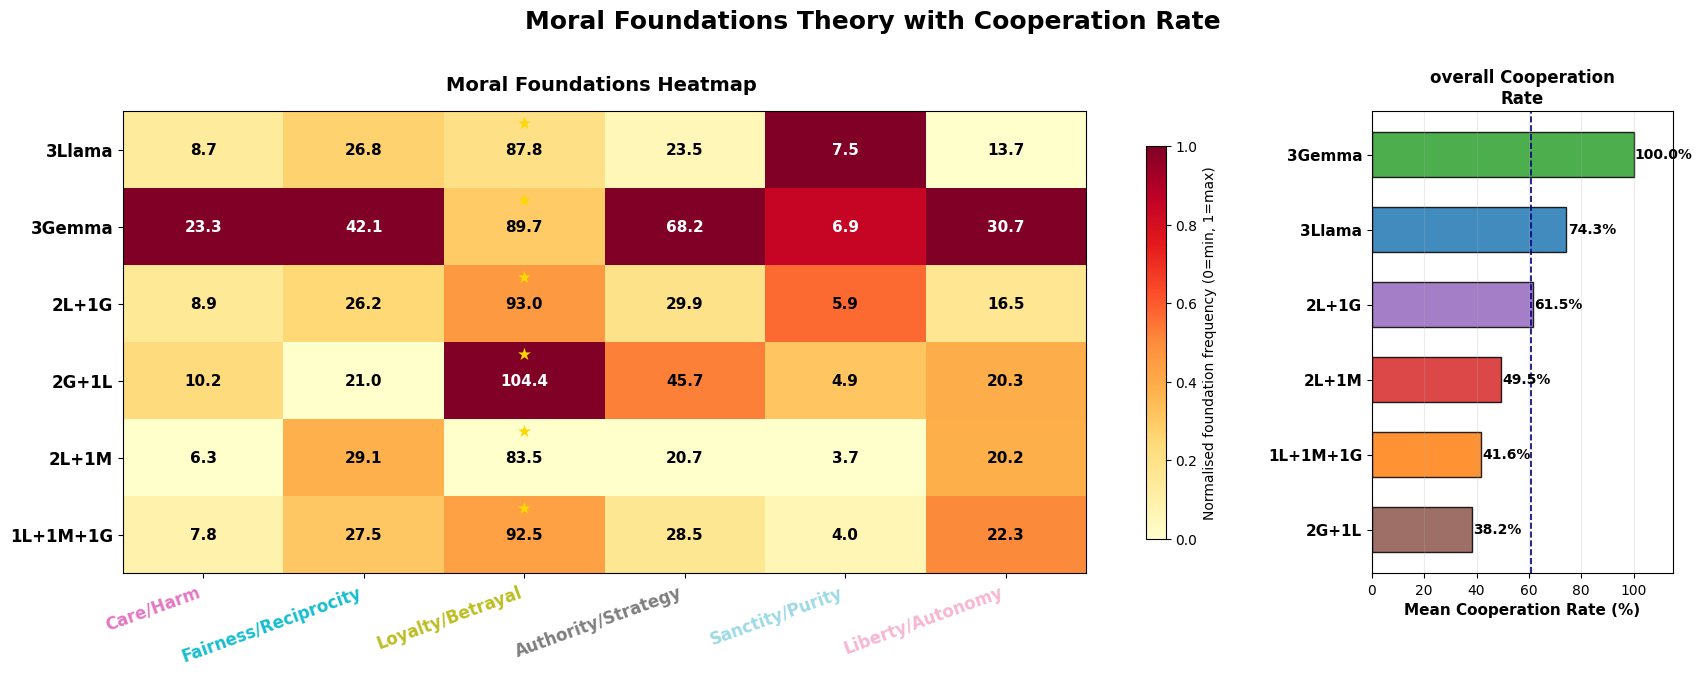

Saved: MFT02_heatmap_coop_20.svg


In [27]:
# ── MFT02 ─────────────────────────────────────────────────────────────────────
# Left : 6×6 heatmap — model mix × MFT foundation (normalised frequency)
# Right: cooperation rate bar chart per mix
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Assume matrix, FOUNDATIONS, COMPS, FOUND_COLORS, COMP_COLORS, and coop_rates exist ---

matrix = np.array([[mft_scores[comp][f] for f in FOUNDATIONS] for comp in COMPS])
# Column-normalise: each foundation scaled 0–1 across the 6 mixes
matrix_norm = (matrix - matrix.min(0)) / (matrix.max(0) - matrix.min(0) + 1e-9)

fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.06)

# ── Left: heatmap ─────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])
im = ax.imshow(matrix_norm, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(6))
ax.set_xticklabels(FOUNDATIONS, fontsize=12, rotation=20, ha="right")
ax.set_yticks(range(6))
# Bolding the Y-axis labels for clarity
ax.set_yticklabels(COMPS, fontsize=12, fontweight="bold")

# Annotate raw scores + highlight dominant foundation per mix
for ri, comp in enumerate(COMPS):
    best_fi = np.argmax(matrix[ri])
    for fi, foundation in enumerate(FOUNDATIONS):
        raw  = matrix[ri, fi]
        norm = matrix_norm[ri, fi]
        color = "white" if norm > 0.7 else "black"
        
        # UPDATED: Enforcing bold font weight for all raw scores, centering alignment
        ax.text(fi, ri, f"{raw:.1f}", ha="center", va="center",
                fontsize=11, color=color, fontweight="bold")
                
    # Star on dominant foundation
    # Adjusted the vertical offset (-0.38 to -0.35) for better visual centering above the text
    ax.text(best_fi, ri - 0.35, "★", ha="center", va="center",
            fontsize=12, color="gold", fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.85, label="Normalised foundation frequency (0=min, 1=max)")

# Centering the heatmap title and bolding it
ax.set_title(
    "Moral Foundations Heatmap ",
    fontsize=14, fontweight="bold", loc="center", pad=15
)

# Foundation color patches in x-axis labels
for fi, (foundation, color) in enumerate(FOUND_COLORS.items()):
    ax.get_xticklabels()[fi].set_color(color)
    ax.get_xticklabels()[fi].set_fontweight("bold")

# ── Right: cooperation rate bars ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
coop_arr = np.array([coop_rates[c] for c in COMPS])
sort_idx = np.argsort(coop_arr)[::-1]
bar_comps = [COMPS[i] for i in sort_idx]
bar_vals  = [coop_arr[i] for i in sort_idx]

bars = ax2.barh(range(6), bar_vals,
                color=[COMP_COLORS[c] for c in bar_comps],
                edgecolor="black", height=0.6, alpha=0.85)
for bi, (bar, val) in enumerate(zip(bars, bar_vals)):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

# Bolding the bar chart Y-labels
ax2.set_yticks(range(6))
ax2.set_yticklabels(bar_comps, fontsize=11, fontweight="bold")
ax2.set_xlim(0, 115)
ax2.set_xlabel("Mean Cooperation Rate (%)", fontsize=11, fontweight="bold")
ax2.axvline(coop_arr.mean(), color="navy", linestyle="--", linewidth=1.2)
ax2.invert_yaxis()

# Centering the bar chart title
ax2.set_title("overall Cooperation\nRate", fontsize=12, fontweight="bold", loc="center")
ax2.grid(axis="x", alpha=0.25)

# Centering the main figure title
fig.suptitle("Moral Foundations Theory with Cooperation Rate",
             fontsize=18, fontweight="bold", y=1.05, ha="center")

# ── UPDATED EXPORT SECTION ───────────────────────────────────────────────
# Save as SVG for unlimited resolution scaling in PowerPoint
plt.savefig("MFT02_heatmap_coop_26.svg", format="svg", bbox_inches="tight")
plt.show()
print("Saved: MFT02_heatmap_coop_20.svg")

Loading condition-level cooperation data...
Done.



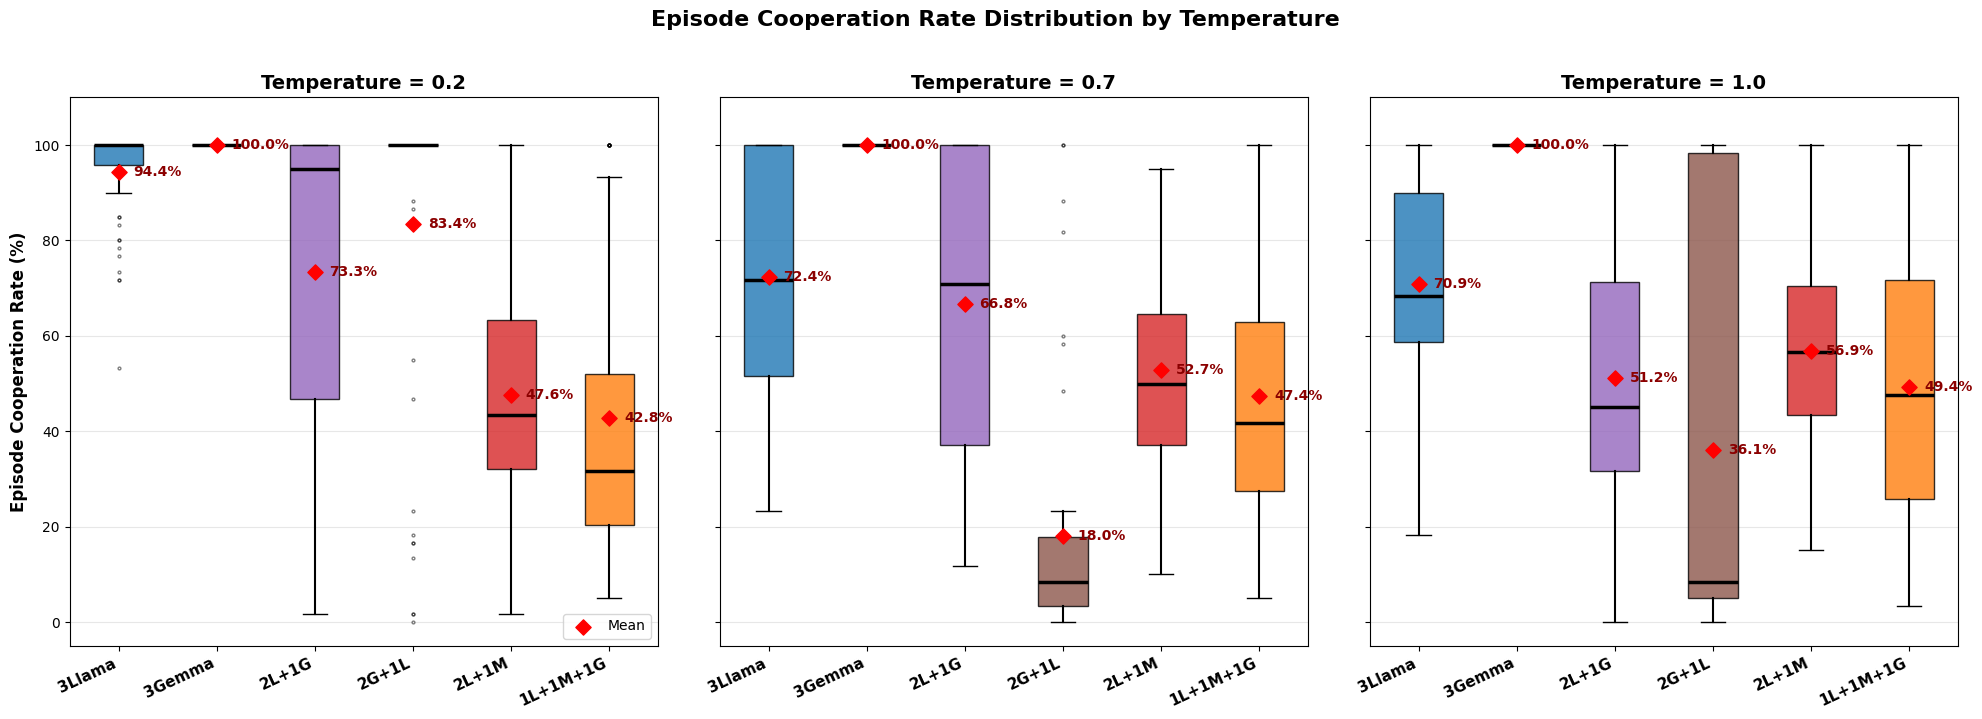

Saved: TH04A_box_by_temperature_HW10_22.svg


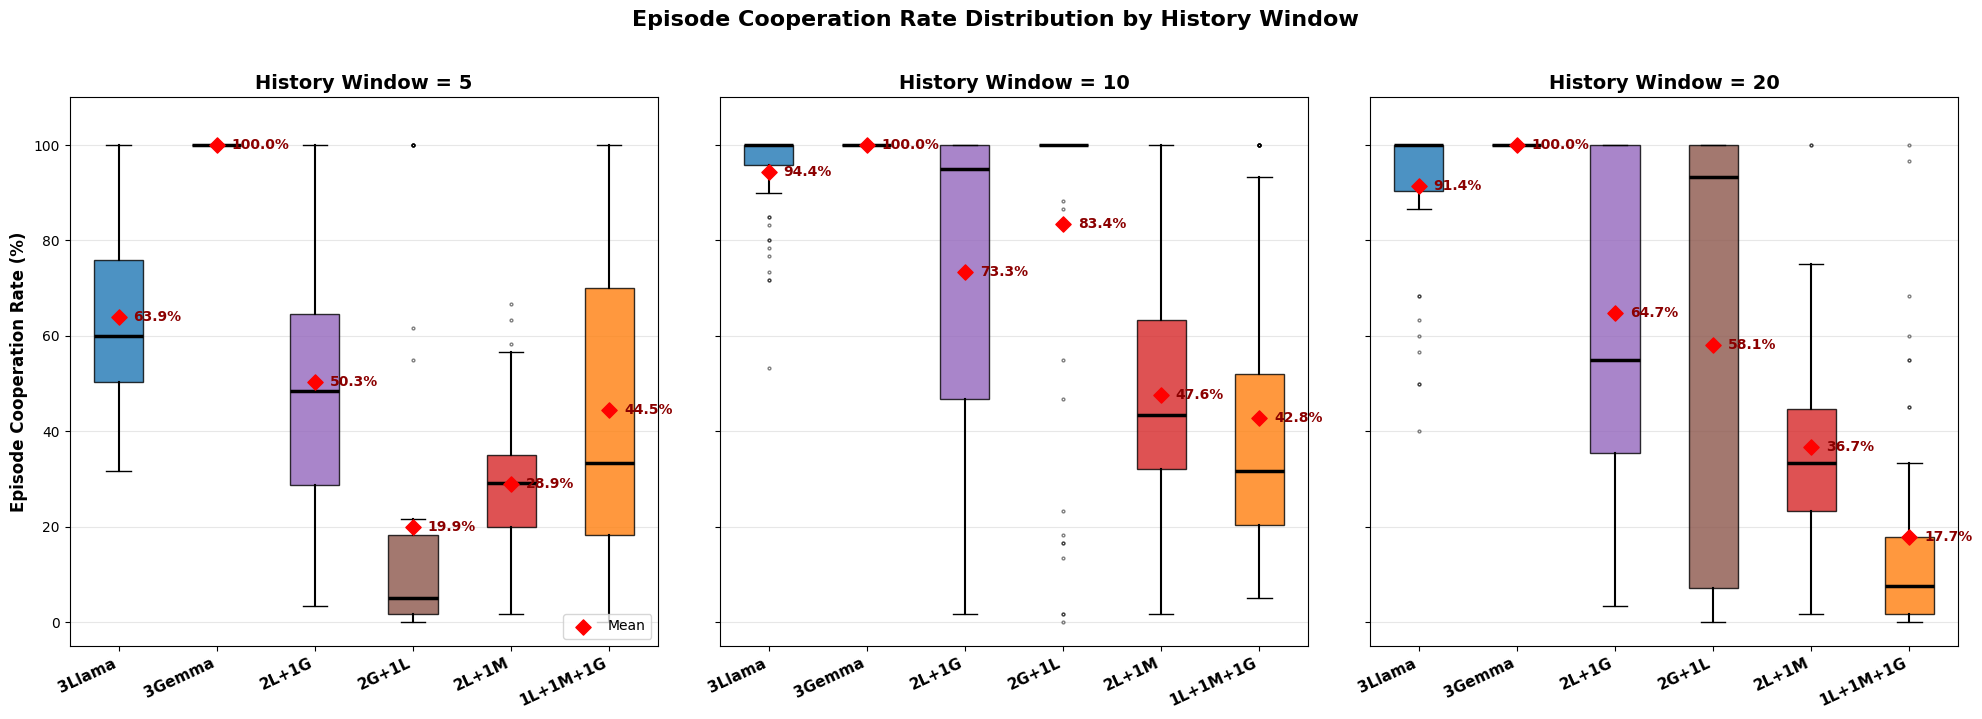

Saved: TH04B_box_by_hw_Temp0.2_22.svg

════════════════════════════════════════════════════════════
 EXACT MEAN COOPERATION RATES PLOTTED
════════════════════════════════════════════════════════════

[FIGURE A] Varying Temperature (Holding HW = 10)
  Temperature 0.2:
    3Llama       :  94.4%
    3Gemma       : 100.0%
    2L+1G        :  73.3%
    2G+1L        :  83.4%
    2L+1M        :  47.6%
    1L+1M+1G     :  42.8%
  Temperature 0.7:
    3Llama       :  72.4%
    3Gemma       : 100.0%
    2L+1G        :  66.8%
    2G+1L        :  18.0%
    2L+1M        :  52.7%
    1L+1M+1G     :  47.4%
  Temperature 1.0:
    3Llama       :  70.9%
    3Gemma       : 100.0%
    2L+1G        :  51.2%
    2G+1L        :  36.1%
    2L+1M        :  56.9%
    1L+1M+1G     :  49.4%

[FIGURE B] Varying History Window (Holding Temp = 0.2)
  History Window 5:
    3Llama       :  63.9%
    3Gemma       : 100.0%
    2L+1G        :  50.3%
    2G+1L        :  19.9%
    2L+1M        :  28.9%
    1L+1M+1G     :  

In [21]:
# ── Shared loader for Section 54 ──────────────────────────────────────────────
import json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FOLDERS = {
    "3Llama":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3",
    "3Gemma":    "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare_history3_temp3_3gemma9",
    "2L+1G":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lama8gemma9",
    "2G+1L":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_2gemma91lama8",
    "2L+1M":     "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/compare_history3_temp3_lam8mistr7",
    "1L+1M+1G":  "/home/rayudu/My_work1/IPD/work/forge/llm/IPD-LLM-Agents3/results/Compare3_history3_temp3_lamma8mistral7gemma9",
}
COMP_COLORS = {
    "3Llama":"#1f77b4","3Gemma":"#2ca02c","2L+1G":"#9467bd",
    "2G+1L":"#8c564b","2L+1M":"#d62728","1L+1M+1G":"#ff7f0e",
}
COMPS = list(FOLDERS.keys())
TEMPS = [0.2, 0.7, 1.0]
HWS   = [5, 10, 20]

def load_cond_data():
    """
    Returns cond_data: {comp: {(T,HW): list of episode mean coop rates (%)}}
    One list per (comp, T, HW) with 50 values (one per episode).
    """
    cond_data = {comp: {} for comp in COMPS}
    for comp, folder in FOLDERS.items():
        for fp in sorted(glob.glob(f"{folder}/*.json")):
            with open(fp) as f:
                d = json.load(f)
            T  = round(d["config"]["temperature"], 1)
            HW = d["config"]["history_window_size"]
            key = (T, HW)
            ep_rates = []
            for ep in d["episodes"]:
                rates = [ep[f"agent_{i}"]["cooperation_rate"] * 100.0
                         for i in range(3) if f"agent_{i}" in ep
                         and "cooperation_rate" in ep[f"agent_{i}"]]
                ep_rates.append(float(np.mean(rates)) if rates else 0.0)
            cond_data[comp].setdefault(key, []).extend(ep_rates)
    # convert to numpy arrays
    for comp in COMPS:
        for key in cond_data[comp]:
            cond_data[comp][key] = np.array(cond_data[comp][key])
    return cond_data

print("Loading condition-level cooperation data...")
COND_DATA = load_cond_data()

# Condition means for quick access
COND_MEAN = {
    comp: {k: float(v.mean()) for k, v in COND_DATA[comp].items()}
    for comp in COMPS
}
print("Done.\n")

# ─────────────────────────────────────────────────────────────────────────────
# ── TH04 ─────────────────────────────────────────────────────────────────────

# ── 1. Configure your exact filters here! ────────────────────────────────────
FILTER_HWS_FOR_TEMP_PLOT   = [10]        # Defines which HWs to include when plotting by Temperature
FILTER_TEMPS_FOR_HW_PLOT   = [0.2]       # Defines which Temps to include when plotting by History Window

hw_label   = ",".join(map(str, FILTER_HWS_FOR_TEMP_PLOT))
temp_label = ",".join(map(str, FILTER_TEMPS_FOR_HW_PLOT))

# ── Figure A: vary Temperature, one panel per T ───────────────────────────────
fig_a, axes_a = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
num_hw_filters = len(FILTER_HWS_FOR_TEMP_PLOT)
fig_a.suptitle("Episode Cooperation Rate Distribution by Temperature",
               fontsize=16, fontweight="bold", y=1.02)

for ti, t in enumerate(TEMPS):
    ax = axes_a[ti]
    data_t = []
    for comp in COMPS:
        vals = np.concatenate([
            COND_DATA[comp].get((t, hw), np.array([]))
            for hw in FILTER_HWS_FOR_TEMP_PLOT
        ])
        data_t.append(vals)

    bp = ax.boxplot(data_t, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2.5),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5),
                    whiskerprops=dict(linewidth=1.5))
    for patch, comp in zip(bp["boxes"], COMPS):
        patch.set_facecolor(COMP_COLORS[comp]); patch.set_alpha(0.8)

    ax.set_xticks(range(1, 7))
    # BOLDED X-Axis Labels
    ax.set_xticklabels(COMPS, rotation=25, ha="right", fontsize=11, fontweight="bold")
    ax.set_title(f"Temperature = {t}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Episode Cooperation Rate (%)" if ti == 0 else "", fontsize=12, fontweight="bold")
    ax.set_ylim(-5, 110)
    ax.grid(axis="y", alpha=0.3)

    # Overlay means as red diamonds AND print the value next to it
    for bi, vals in enumerate(data_t):
        if len(vals) > 0:
            mean_val = vals.mean()
            ax.scatter(bi+1, mean_val, marker="D", color="red",
                       s=60, zorder=5, label="Mean" if bi == 0 else "")
            # NEW: Add bold text label for the mean value
            ax.text(bi+1.15, mean_val, f"{mean_val:.1f}%", va="center", 
                    fontsize=10, fontweight="bold", color="darkred")

    if ti == 0:
        ax.legend(fontsize=10, loc="lower right")

plt.tight_layout()
# UPDATED: Export as SVG
plt.savefig(f"TH04A_box_by_temperature_HW{hw_label}_24.svg", format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: TH04A_box_by_temperature_HW{hw_label}_22.svg")

# ── Figure B: vary History Window, one panel per HW ──────────────────────────
fig_b, axes_b = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
num_temp_filters = len(FILTER_TEMPS_FOR_HW_PLOT)
fig_b.suptitle("Episode Cooperation Rate Distribution by History Window",
               fontsize=16, fontweight="bold", y=1.02)

for hi, hw in enumerate(HWS):
    ax = axes_b[hi]
    data_hw = []
    for comp in COMPS:
        vals = np.concatenate([
            COND_DATA[comp].get((t, hw), np.array([]))
            for t in FILTER_TEMPS_FOR_HW_PLOT
        ])
        data_hw.append(vals)

    bp = ax.boxplot(data_hw, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2.5),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5),
                    whiskerprops=dict(linewidth=1.5))
    for patch, comp in zip(bp["boxes"], COMPS):
        patch.set_facecolor(COMP_COLORS[comp]); patch.set_alpha(0.8)

    ax.set_xticks(range(1, 7))
    # BOLDED X-Axis Labels
    ax.set_xticklabels(COMPS, rotation=25, ha="right", fontsize=11, fontweight="bold")
    ax.set_title(f"History Window = {hw}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Episode Cooperation Rate (%)" if hi == 0 else "", fontsize=12, fontweight="bold")
    ax.set_ylim(-5, 110)
    ax.grid(axis="y", alpha=0.3)

    # Overlay means as red diamonds AND print the value next to it
    for bi, vals in enumerate(data_hw):
        if len(vals) > 0:
            mean_val = vals.mean()
            ax.scatter(bi+1, mean_val, marker="D", color="red", s=60, 
                       zorder=5, label="Mean" if bi == 0 else "")
            # NEW: Add bold text label for the mean value
            ax.text(bi+1.15, mean_val, f"{mean_val:.1f}%", va="center", 
                    fontsize=10, fontweight="bold", color="darkred")
            
    if hi == 0:
        ax.legend(fontsize=10, loc="lower right")

plt.tight_layout()
# UPDATED: Export as SVG
plt.savefig(f"TH04B_box_by_hw_Temp{temp_label}_24.svg", format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: TH04B_box_by_hw_Temp{temp_label}_22.svg")


# ── 4. Print Exact Mean Values ───────────────────────────────────────────────
print("\n" + "═" * 60)
print(" EXACT MEAN COOPERATION RATES PLOTTED")
print("═" * 60)

print(f"\n[FIGURE A] Varying Temperature (Holding HW = {hw_label})")
for t in TEMPS:
    print(f"  Temperature {t}:")
    for comp in COMPS:
        vals = np.concatenate([
            COND_DATA[comp].get((t, hw), np.array([]))
            for hw in FILTER_HWS_FOR_TEMP_PLOT
        ])
        mean_val = vals.mean() if len(vals) > 0 else 0.0
        print(f"    {comp:<12} : {mean_val:>5.1f}%")

print(f"\n[FIGURE B] Varying History Window (Holding Temp = {temp_label})")
for hw in HWS:
    print(f"  History Window {hw}:")
    for comp in COMPS:
        vals = np.concatenate([
            COND_DATA[comp].get((t, hw), np.array([]))
            for t in FILTER_TEMPS_FOR_HW_PLOT
        ])
        mean_val = vals.mean() if len(vals) > 0 else 0.0
        print(f"    {comp:<12} : {mean_val:>5.1f}%")
print("═" * 60 + "\n")